# Aula prática – Keras para TinyML
## Classificação de atividades humanas (HAR) com o dataset WISDM

### Objetivo
Vamos seguir o mesmo fluxo típico de TinyML da aula de anomalia térmica, mas agora com **dados reais de acelerômetro** do dataset WISDM:

1. carregar os dados do acelerômetro;
2. criar janelas;
3. extrair features;
4. treinar uma rede neural pequena;
5. avaliar o modelo;
6. converter para `.tflite`;
7. rodar inferência com TensorFlow Lite em Python.

### Pergunta central
Como aplicar o mesmo pipeline de TinyML a um problema real de reconhecimento de atividades a partir de um sensor de movimento?


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers

## 1. Contexto do problema

O dataset **WISDM** (Wireless Sensor Data Mining) contém leituras de acelerômetro de smartphones
de 36 usuários realizando 6 atividades:

- `Walking` (andar)
- `Jogging` (correr)
- `Upstairs` (subir escadas)
- `Downstairs` (descer escadas)
- `Sitting` (sentado)
- `Standing` (em pé)

Cada leitura tem 3 eixos de aceleração: **x, y, z**.

### Nossa estratégia
Em vez de classificar uma única leitura, vamos usar **janelas de leituras** para capturar o
padrão de movimento ao longo do tempo. Cada janela será resumida em features estatísticas
por eixo (média, desvio padrão e máximo), que serão a entrada da rede neural.


In [ ]:
columns = ['user', 'activity', 'timestamp', 'x-accel', 'y-accel', 'z-accel']
raw_path = './WISDM_ar_v1.1_raw.txt'

with open(raw_path, 'r') as f:
    content = f.read()

records = []
for record in content.split(';'):
    fields = record.strip().split(',')
    if len(fields) == 6 and fields[0] != '':
        records.append(fields)

df = pd.DataFrame(records, columns=columns)

df['user'] = df['user'].astype(int)
df['timestamp'] = df['timestamp'].astype('int64')
df['x-accel'] = pd.to_numeric(df['x-accel'], errors='coerce')
df['y-accel'] = pd.to_numeric(df['y-accel'], errors='coerce')
df['z-accel'] = pd.to_numeric(df['z-accel'], errors='coerce')

df = df.dropna().reset_index(drop=True)

print(f'Total de registros: {len(df)}')
df.head()

Total de registros: 1086474


,user,activity,timestamp,x-accel,y-accel,z-accel
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164


In [5]:
print("Distribuição das atividades:")
print(df["activity"].value_counts())

Distribuição das atividades:
activity
Walking       418394
Jogging       336450
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


## 2. Visualizando o sinal

Vamos observar o comportamento dos 3 eixos do acelerômetro para algumas atividades.

### O que esperamos ver?
- atividades dinâmicas (`Walking`, `Jogging`) têm sinais com muita oscilação e padrões periódicos;
- atividades estáticas (`Sitting`, `Standing`) têm sinais quase constantes.


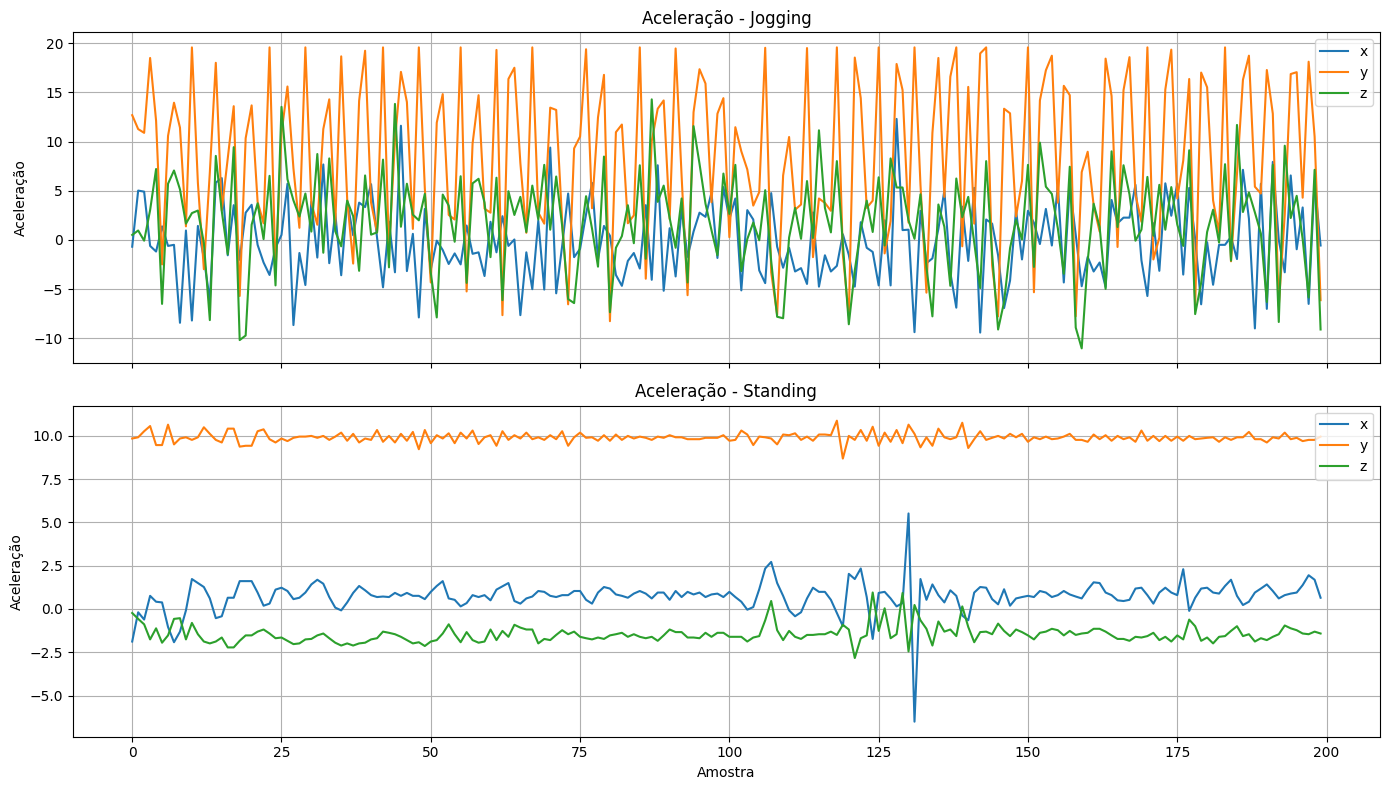

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, atividade in zip(axes, ["Jogging", "Standing"]):
    trecho = df[df["activity"] == atividade].head(200)
    ax.plot(trecho["x-accel"].values, label="x")
    ax.plot(trecho["y-accel"].values, label="y")
    ax.plot(trecho["z-accel"].values, label="z")
    ax.set_title(f"Aceleração - {atividade}")
    ax.set_ylabel("Aceleração")
    ax.grid(True)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Amostra")
plt.tight_layout()
plt.show()

## 3. Criando janelas e features

### Por que usar janelas?
Uma leitura isolada de aceleração não diz muito.
Uma janela de leituras captura o **padrão de movimento** ao longo do tempo.

### Features da janela
Para cada janela de 80 leituras (~4 segundos a 20 Hz), vamos calcular, **para cada eixo (x, y, z)**:
- média
- desvio padrão
- máximo

Isso resulta em `3 eixos x 3 features = 9 features` por janela, que formam a entrada da rede neural.

### Rótulo da janela
O rótulo da janela é a atividade que mais aparece dentro dela (voto da maioria).


In [7]:
WINDOW_SIZE = 80   # ~4 s de dados a 20 Hz
STEP = 40          # 50% de sobreposicao entre janelas
AXES = ["x-accel", "y-accel", "z-accel"]


def create_sliding_windows(frame, window_size=WINDOW_SIZE, step=STEP):
    X_windows = []
    y_windows = []

    valores = frame[AXES].values
    atividades = frame["activity"].values

    for i in range(0, len(frame) - window_size + 1, step):
        janela = valores[i:i + window_size]
        rotulos = atividades[i:i + window_size]

        # rotulo = atividade mais frequente na janela (voto da maioria)
        rotulo = pd.Series(rotulos).mode()[0]

        X_windows.append(janela)
        y_windows.append(rotulo)

    return np.array(X_windows), np.array(y_windows)


def extract_features(windows):
    features = []
    for janela in windows:
        feats = []
        for eixo in range(janela.shape[1]):
            sinal = janela[:, eixo]
            feats.append(np.mean(sinal))
            feats.append(np.std(sinal))
            feats.append(np.max(sinal))
        features.append(feats)
    return np.array(features)

In [8]:
# Ordena por usuario e tempo para que as janelas respeitem a sequencia temporal
df_sorted = df.sort_values(["user", "timestamp"]).reset_index(drop=True)

X_windows, y_labels = create_sliding_windows(df_sorted)
X_features = extract_features(X_windows)

print("Formato das janelas:", X_windows.shape)
print("Formato das features:", X_features.shape)
print("Formato dos rotulos:", y_labels.shape)

Formato das janelas: (27160, 80, 3)
Formato das features: (27160, 9)
Formato dos rotulos: (27160,)


## 4. Entendendo a entrada da rede neural

Cada janela agora é representada por **9 números**:

`[média_x, desvio_x, máximo_x, média_y, desvio_y, máximo_y, média_z, desvio_z, máximo_z]`

Portanto:
- cada amostra tem **9 entradas**;
- a rede neural deve receber vetores no formato `(9,)`.

### Regra geral
Número de entradas da rede = número de features por amostra


In [9]:
feature_names = [
    "media_x", "desvio_x", "maximo_x",
    "media_y", "desvio_y", "maximo_y",
    "media_z", "desvio_z", "maximo_z",
]

features_df = pd.DataFrame(X_features, columns=feature_names)
features_df["activity"] = y_labels
features_df.head()

,media_x,desvio_x,maximo_x,media_y,desvio_y,maximo_y,media_z,desvio_z,maximo_z,activity
0,3.643500,5.449704,19.57,9.784250,3.749458,19.23,-0.390500,3.412389,10.88,Walking
1,3.671750,5.797496,19.57,9.904750,4.198527,19.50,-0.607125,3.542371,12.11,Walking
2,3.824500,5.939786,19.57,10.015750,4.494045,19.50,-0.739750,2.970321,12.11,Walking
3,3.864500,5.815026,19.57,10.122375,4.401588,19.11,-0.693375,3.238339,10.61,Walking
4,3.976625,5.753998,19.57,10.021500,4.489350,19.50,-0.442250,3.656289,11.50,Walking


## 5. Codificando os rótulos

Diferente do problema térmico (binário: 0/1), aqui temos **6 classes**.
Vamos converter os nomes das atividades em números inteiros (0 a 5).


In [ ]:
classes = sorted(np.unique(y_labels))
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y_encoded = np.array([class_to_idx[a] for a in y_labels])

print("Classes:", classes)
print("Mapeamento:", class_to_idx)

## 6. Separando treino e teste

Vamos dividir os dados em treino e teste, usando `stratify` para manter
a proporção das classes nos dois conjuntos.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

## 7. Normalizando as features

As features de aceleração têm escalas diferentes (média, desvio e máximo variam bastante).
Redes neurais treinam melhor com entradas normalizadas, então vamos padronizar
(`média 0`, `desvio 1`) usando o `StandardScaler`.

> Importante: o scaler é ajustado **apenas no treino** e depois aplicado ao teste.
> Os parâmetros do scaler também precisam ser usados na inferência no dispositivo.


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Media (treino):", np.round(scaler.mean_, 3))
print("Escala (treino):", np.round(scaler.scale_, 3))

## 8. Criando a rede neural com Keras

Agora vamos criar uma rede neural pequena, adequada para TinyML.

### Estrutura escolhida
- entrada com 9 valores;
- camada oculta com 32 neurônios (`relu`);
- camada oculta com 16 neurônios (`relu`);
- saída com 6 neurônios (`softmax`).

### Por que `softmax` na saída?
Porque agora o problema é **multiclasse**: a saída é uma distribuição de
probabilidade sobre as 6 atividades, e escolhemos a de maior probabilidade.


In [ ]:
num_classes = len(classes)

model = keras.Sequential([
    layers.Input(shape=(9,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

## 9. Compilando o modelo

### Elementos importantes
- `optimizer="adam"`: método de ajuste dos pesos;
- `loss="sparse_categorical_crossentropy"`: perda adequada para classificação multiclasse com rótulos inteiros;
- `metrics=["accuracy"]`: métrica para acompanhar o desempenho.


In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

## 10. Treinando o modelo

- `epochs`: quantas vezes o modelo verá o conjunto de treino;
- `batch_size`: quantas amostras são processadas por vez;
- `validation_split`: separa parte do treino para validação.


In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=1
)

## 11. Visualizando o treinamento

Vamos observar a perda (`loss`) e a acurácia (`accuracy`) para entender
se o modelo está aprendendo e se há sobreajuste.


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validacao")
plt.title("Loss")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validacao")
plt.title("Accuracy")
plt.xlabel("Epoca")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

## 12. Avaliando o modelo

Vamos avaliar no conjunto de teste com acurácia, relatório por classe
e matriz de confusão.


In [ ]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print(f"Acuracia: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap="Greens", ax=ax, xticks_rotation=45)
plt.title("Matriz de confusao")
plt.tight_layout()
plt.show()

## 13. Salvando o modelo Keras


In [ ]:
model.save("wisdm_model.keras")
print("Modelo salvo em wisdm_model.keras")

## 14. Convertendo para TensorFlow Lite

O TensorFlow Lite gera um modelo leve (`.tflite`), próprio para rodar em
dispositivos com poucos recursos (microcontroladores, celulares).


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("wisdm_model.tflite", "wb") as f:
    f.write(tflite_model)

print("Modelo salvo em wisdm_model.tflite")
print(f"Tamanho do modelo: {len(tflite_model)} bytes")

## 15. Carregando o modelo TFLite

Vamos carregar o interpretador e inspecionar os tensores de entrada e saída.


In [ ]:
interpreter = tf.lite.Interpreter(model_path="wisdm_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Entrada:", input_details)
print("Saida:", output_details)

## 16. Rodando inferência com TFLite

A função abaixo recebe as 9 features **já normalizadas** de uma janela,
roda o modelo `.tflite` e retorna a atividade prevista e o score.


In [ ]:
def tflite_predict(sample_features):
    sample = np.array([sample_features], dtype=np.float32)
    interpreter.set_tensor(input_details[0]["index"], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]["index"])[0]
    idx = int(np.argmax(output))
    return idx_to_class[idx], float(output[idx])

In [ ]:
acertos = 0
n = 30

for i in range(n):
    sample = X_test_scaled[i]
    true_label = idx_to_class[y_test[i]]
    pred, score = tflite_predict(sample)

    if pred == true_label:
        acertos += 1

    print(f"Amostra {i}")
    print(f"Score: {score:.4f}")
    print(f"Predicao: {pred}")
    print(f"Real: {true_label}")
    print("-" * 50)

print(f"\nAcertos nas {n} amostras: {acertos}/{n}")

## 17. O que aprendemos?

Aplicamos o **mesmo fluxo de TinyML** da aula de anomalia térmica, agora com
**dados reais de acelerômetro** (WISDM):

- carregamento e limpeza dos dados;
- janelas deslizantes sobre os 3 eixos;
- extração de features (média, desvio, máximo por eixo);
- normalização das features;
- rede neural pequena com Keras (multiclasse, `softmax`);
- treino e avaliação;
- conversão para `.tflite`;
- inferência com TensorFlow Lite.

### Ideia principal
O pipeline de TinyML é o mesmo, mude o problema de **binário (anomalia)** para
**multiclasse (6 atividades)** ajustando: a saída da rede (`softmax`), a função de
perda (`sparse_categorical_crossentropy`) e a forma como extraímos features de um
sinal multivariado (x, y, z).
